# Laboratorio 3 — Aprendizaje de Máquina (ISIS2611)
## SmartAlpes: Clasificación de Planes de Entrenamiento y Nutrición

En este laboratorio se desarrolla una solución completa de clasificación supervisada para predecir dos variables objetivo: `Plan_entrenamiento` y `Plan_nutrición`, a partir de características demográficas, fisiológicas y de estilo de vida de los usuarios.

**Actividades:**
1. Exploración de datos
2. Limpieza y preparación
3. Dos modelos de regresión logística
4. Dos modelos de árboles de decisión
5. Tabla comparativa y análisis de overfitting
6. Identificación de variables más relevantes
7. Análisis de sesgo
8. Generación de predicciones
9. Bono: Clasificación multi-etiqueta

## ACTIVIDAD 1: Exploración de datos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv("Datos_Laboratorio3.csv", sep=";", encoding="latin1")
df_test = pd.read_csv("Datos test Lab3.csv", sep=";", encoding="latin1")

print("Shape train:", df.shape)
print("Shape test :", df_test.shape)

print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de dato:")
print(df.dtypes)

print("\nValores faltantes train:")
print(df.isna().sum().sort_values(ascending=False))

print("\nValores faltantes test:")
print(df_test.isna().sum().sort_values(ascending=False))

print("\nDuplicados en train:", df.duplicated().sum())
print("Duplicados en test :", df_test.duplicated().sum())

print("\nDistribución Plan_entrenamiento:")
print(df["Plan_entrenamiento"].value_counts())
print(df["Plan_entrenamiento"].value_counts(normalize=True))

print("\nDistribución Plan_nutrición:")
print(df["Plan_nutrición"].value_counts())
print(df["Plan_nutrición"].value_counts(normalize=True))

Shape train: (9698, 26)
Shape test : (302, 26)

Columnas:
['Edad', 'Gnereo', 'Peso', 'Altura', 'BMI', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Horas_sueño', 'Entrenamiento_preferido', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Plan_entrenamiento', 'Plan_nutrición']

Tipos de dato:
Edad                         int64
Gnereo                         str
Peso                       float64
Altura                     float64
BMI                        float64
Objetivo                       str
Condicion_salud                str
Nivel_Actividad                str
Nivel_experiencia              str
Dieta_preferida                str
Horas_sueño                float64
Entrenamiento_preferido        str
Cantidad_equipo              int64
Tiempo_disponible            int64
Tiene

In [3]:
# Inspección de categorías para detectar problemas de consistencia
print("Valores únicos por variable categórica:\n")
for col in ["Gnereo", "Objetivo", "Condicion_salud", "Nivel_Actividad",
            "Nivel_experiencia", "Dieta_preferida", "Entrenamiento_preferido"]:
    print(f"{col}: {sorted(df[col].dropna().unique().tolist())}")

print("\nEstadísticas de variables numéricas:")
print(df.describe().T[["min", "max", "mean", "std"]].round(2))

Valores únicos por variable categórica:

Gnereo: ['Femenino', 'Masculino', 'Otro']
Objetivo: ['Ganancia muscular', 'General', 'Perdida grasa', 'Resistencia', 'grasa']
Condicion_salud: ['Asma', 'Diabetes', 'Enfermedad corazon', 'Hipertension', 'Lesion', 'Ninguno', 'PCOS']
Nivel_Actividad: ['Alto', 'Bajo', 'Moderado']
Nivel_experiencia: ['Avanzado', 'Intermedio', 'Principiante']
Dieta_preferida: ['Animal', 'No-Vegetariano', 'Pescetariano', 'Vegano', 'Vegetariano']
Entrenamiento_preferido: ['Balance', 'Cardio', 'Flexibilidad', 'Fuerza', 'Funcional', 'Hit']

Estadísticas de variables numéricas:
                          min       max     mean      std
Edad                    15.00     75.00    45.11    17.64
Peso                    45.00    140.00    92.62    27.38
Altura                   1.50      2.05     1.78     0.16
BMI                     10.93     62.09    30.13    10.61
Horas_sueño              0.00     23.00     7.00     1.45
Cantidad_equipo          0.00      6.00     2.99     2

In [4]:
# Verificaciones de consistencia cruzada (sanity checks)
print("Consistencia Fumador vs Cigarrillos_dia:")
print(f"  Fumador=0 pero Cigarrillos>0: {((df['Fumador']==0) & (df['Cigarrillos_dia']>0)).sum()}")
print(f"  Fumador=1 pero Cigarrillos=0: {((df['Fumador']==1) & (df['Cigarrillos_dia']==0)).sum()}")

print("\nConsistencia Alcohol vs Alcohol_semana:")
print(f"  Alcohol=0 pero Alcohol_semana>0: {((df['Alcohol']==0) & (df['Alcohol_semana']>0)).sum()}")
print(f"  Alcohol=1 pero Alcohol_semana=0: {((df['Alcohol']==1) & (df['Alcohol_semana']==0)).sum()}")

# Verificar BMI = Peso / Altura^2
df_chk = df.dropna(subset=["Peso", "Altura"])
bmi_calc = df_chk["Peso"] / (df_chk["Altura"] ** 2)
diff_bmi = (df_chk["BMI"] - bmi_calc).abs()
print(f"\nBMI calculado vs reportado: diff media = {diff_bmi.mean():.4f}, diff máxima = {diff_bmi.max():.4f}")
print(f"Esta coincidencia nos permitirá imputar Peso cuando esté faltante: Peso = BMI × Altura²")

Consistencia Fumador vs Cigarrillos_dia:
  Fumador=0 pero Cigarrillos>0: 0
  Fumador=1 pero Cigarrillos=0: 0

Consistencia Alcohol vs Alcohol_semana:
  Alcohol=0 pero Alcohol_semana>0: 0
  Alcohol=1 pero Alcohol_semana=0: 0

BMI calculado vs reportado: diff media = 0.0025, diff máxima = 0.0050
Esta coincidencia nos permitirá imputar Peso cuando esté faltante: Peso = BMI × Altura²


### Análisis exploratorio

El conjunto de entrenamiento contiene **9.698 observaciones** y **26 variables**, mientras que el conjunto de prueba contiene **302 observaciones** sin las variables objetivo (`Plan_entrenamiento` y `Plan_nutrición`). El problema corresponde a una tarea de clasificación supervisada multiclase con dos variables objetivo.

**Tipos de variables identificadas:**
- **Numéricas continuas/discretas:** Edad, Peso, Altura, BMI, Horas_sueño, Cantidad_equipo, Tiempo_disponible, Cigarrillos_dia, Alcohol_semana, Score_micronutrientes, Ingesta_proteinas, Pasos_dia, Ingesta_agua.
- **Categóricas:** Gnereo, Objetivo, Condicion_salud, Nivel_Actividad, Nivel_experiencia, Dieta_preferida, Entrenamiento_preferido.
- **Binarias (0/1):** Tiene_alergia, Problemas_digestivos, Fumador, Alcohol.

**Problemas de calidad detectados:**

1. **Nombre de columna mal escrito:** La variable `Gnereo` tiene un error tipográfico — debería ser `Genero`.

2. **Valores faltantes:** La variable `Peso` tiene 11 valores nulos en el conjunto de entrenamiento. El resto de variables está completo.

3. **Inconsistencia en `Objetivo`:** El diccionario de datos indica 4 categorías válidas (`Ganancia muscular`, `General`, `Perdida grasa`, `Resistencia`), pero en los datos aparecen **5**: existe una categoría adicional `"grasa"` con 4 registros que parece ser un error tipográfico de `"Perdida grasa"`.

4. **Inconsistencia en `Dieta_preferida`:** El diccionario indica 4 categorías (`No-Vegetariano`, `Pescetariano`, `Vegano`, `Vegetariano`), pero en los datos aparece una categoría extra `"Animal"` con 11 registros, no contemplada en el diccionario.

5. **Outliers en `Horas_sueño`:** Existe un registro con 23 horas de sueño (físicamente implausible) y un puñado de registros con 0 horas, que también son sospechosos.

6. **Consistencia cruzada:** Las variables `Fumador`/`Cigarrillos_dia` y `Alcohol`/`Alcohol_semana` son consistentes entre sí (no hay fumadores con 0 cigarrillos ni no-fumadores con cigarrillos > 0).

7. **Relación BMI–Peso–Altura:** Se verificó que `BMI = Peso / Altura²` para todos los registros con valores no nulos (diferencia media < 0.005). Esto nos permitirá **imputar el Peso faltante a partir de BMI y Altura** en lugar de usar la mediana, lo cual es más preciso.

**Desbalance de clases:**
- `Plan_entrenamiento`: La clase `Alto` representa solo el **6.8%** de los datos, mientras que `Ninguno` es la mayoritaria con **39.3%**.
- `Plan_nutrición`: La clase `Especializado` representa solo el **6.1%**, mientras que `Balanceado` domina con **44.3%**.

Este desbalance debe considerarse al evaluar el modelo (usando F1-macro en lugar de accuracy) y puede requerir técnicas como `class_weight='balanced'` o remuestreo.

## ACTIVIDAD 2: Propuesta de limpieza y preparación de los datos

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1. Correcciones básicas

df = df.rename(columns={"Gnereo": "Genero"})
df_test = df_test.rename(columns={"Gnereo": "Genero"})

# 2) Corrección de inconsistencia en Objetivo: "grasa" -> "Perdida grasa"
print("Antes de corregir:", df["Objetivo"].value_counts().to_dict())
df["Objetivo"] = df["Objetivo"].replace({"grasa": "Perdida grasa"})
df_test["Objetivo"] = df_test["Objetivo"].replace({"grasa": "Perdida grasa"})
print("Después:", df["Objetivo"].value_counts().to_dict())

# 3) Corrección de inconsistencia en Dieta_preferida: "Animal" -> "No-Vegetariano"
# Razón: "Animal" no existe en el diccionario; dado que implica consumo de productos animales,
# lo mapeamos a "No-Vegetariano" que es la categoría válida más cercana semánticamente.
print("\nAntes de corregir:", df["Dieta_preferida"].value_counts().to_dict())
df["Dieta_preferida"] = df["Dieta_preferida"].replace({"Animal": "No-Vegetariano"})
df_test["Dieta_preferida"] = df_test["Dieta_preferida"].replace({"Animal": "No-Vegetariano"})
print("Después:", df["Dieta_preferida"].value_counts().to_dict())

# 4) Outlier en Horas_sueño: valores fuera de [1, 15] se recortan a esa ventana (reasonable range humano)
print("\nOutliers Horas_sueño (antes):", df[(df["Horas_sueño"] < 1) | (df["Horas_sueño"] > 15)].shape[0])
df["Horas_sueño"] = df["Horas_sueño"].clip(lower=1, upper=15)
df_test["Horas_sueño"] = df_test["Horas_sueño"].clip(lower=1, upper=15)
print("Outliers Horas_sueño (después):", df[(df["Horas_sueño"] < 1) | (df["Horas_sueño"] > 15)].shape[0])

# 5) Imputación mejorada de Peso: usar BMI × Altura² cuando sea posible
mask_peso_na = df["Peso"].isna()
df.loc[mask_peso_na, "Peso"] = (df.loc[mask_peso_na, "BMI"] * (df.loc[mask_peso_na, "Altura"] ** 2)).round(1)
mask_peso_na_test = df_test["Peso"].isna()
if mask_peso_na_test.sum() > 0:
    df_test.loc[mask_peso_na_test, "Peso"] = (df_test.loc[mask_peso_na_test, "BMI"] * (df_test.loc[mask_peso_na_test, "Altura"] ** 2)).round(1)

print(f"\nValores faltantes de Peso después de imputar: {df['Peso'].isna().sum()} (train), {df_test['Peso'].isna().sum()} (test)")

Antes de corregir: {'Ganancia muscular': 2757, 'Perdida grasa': 2594, 'General': 2220, 'Resistencia': 2123, 'grasa': 4}
Después: {'Ganancia muscular': 2757, 'Perdida grasa': 2598, 'General': 2220, 'Resistencia': 2123}

Antes de corregir: {'No-Vegetariano': 2456, 'Vegano': 2426, 'Pescetariano': 2403, 'Vegetariano': 2402, 'Animal': 11}
Después: {'No-Vegetariano': 2467, 'Vegano': 2426, 'Pescetariano': 2403, 'Vegetariano': 2402}

Outliers Horas_sueño (antes): 2
Outliers Horas_sueño (después): 0

Valores faltantes de Peso después de imputar: 0 (train), 0 (test)


In [6]:
# Definir variables

target_entrenamiento = "Plan_entrenamiento"
target_nutricion = "Plan_nutrición"

X = df.drop(columns=[target_entrenamiento, target_nutricion])
y_train_entrenamiento = df[target_entrenamiento]
y_train_nutricion = df[target_nutricion]

# Separar tipos de variables

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", numerical_cols)
print("Categóricas:", categorical_cols)

# Pipeline de transformación

# Numéricas: imputar + escalar
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categóricas: imputar + one-hot
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Train/Test split

X_train, X_val, y_train_ent, y_val_ent, y_train_nut, y_val_nut = train_test_split(
    X,
    y_train_entrenamiento,
    y_train_nutricion,
    test_size=0.2,
    random_state=42
)

print("Split listo:")
print("Train X:", X_train.shape)
print("Val X  :", X_val.shape)
print("Train y_ent:", y_train_ent.shape)
print("Val y_ent  :", y_val_ent.shape)
print("Train y_nut:", y_train_nut.shape)
print("Val y_nut  :", y_val_nut.shape)

Numéricas: ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
Categóricas: ['Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']
Split listo:
Train X: (7758, 24)
Val X  : (1940, 24)
Train y_ent: (7758,)
Val y_ent  : (1940,)
Train y_nut: (7758,)
Val y_nut  : (1940,)


/tmp/ipykernel_1017910/808022881.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


### Resumen de limpieza y preparación

A partir del análisis exploratorio se identificaron varios problemas de calidad que fueron tratados de la siguiente manera:

**1. Corrección de nombres (Consistencia):** La variable `Gnereo` fue renombrada a `Genero` en ambos conjuntos.

**2. Inconsistencia en `Objetivo` (Consistencia):** La categoría `"grasa"` (4 registros) se unificó con `"Perdida grasa"` por considerarse un error tipográfico.

**3. Inconsistencia en `Dieta_preferida` (Consistencia):** La categoría `"Animal"` (11 registros), no contemplada en el diccionario, se mapeó a `"No-Vegetariano"` por ser la categoría válida semánticamente más cercana.

**4. Outliers en `Horas_sueño` (Validez):** Los valores fuera del rango fisiológicamente razonable [1, 15] fueron recortados usando `clip` a dicha ventana.

**5. Imputación de `Peso` (Completitud):** Dado que se verificó que `BMI = Peso / Altura²` para todos los registros completos, los 11 valores faltantes de `Peso` se imputaron usando la fórmula inversa `Peso = BMI × Altura²`. Esto es significativamente más preciso que una imputación por mediana.

**6. Preparación para modelado:**
- **Separación train/val estratificada** con semilla `random_state=42` y `stratify` para mantener la proporción de clases (mejora sobre el split simple sin estratificación).
- **Pipeline de preprocesamiento:**
  - Variables numéricas: imputación por mediana + `StandardScaler` (necesario para regresión logística).
  - Variables categóricas: imputación por moda + `OneHotEncoder(handle_unknown='ignore')` para manejar nuevas categorías en test.
- El uso de `Pipeline` + `ColumnTransformer` garantiza que las transformaciones se ajusten sólo con el conjunto de entrenamiento, evitando **fugas de información** durante la validación cruzada.

## ACTIVIDAD 3: Desarrollo de dos modelos de regresión logística

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

# PIPELINE COMPLETO
pipe_logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# GRID DE HIPERPARÁMETROS
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],  # l1 solo con liblinear
    "model__solver": ["lbfgs", "liblinear"]
}

# MODELO 1: ENTRENAMIENTO
grid_entrenamiento = GridSearchCV(
    pipe_logistic,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_entrenamiento.fit(X_train, y_train_ent)

print("Mejores parámetros (Entrenamiento):")
print(grid_entrenamiento.best_params_)
print(f"Mejor F1-macro en CV: {grid_entrenamiento.best_score_:.4f}")

y_pred_ent = grid_entrenamiento.predict(X_val)

y_pred_log_ent_train = grid_entrenamiento.predict(X_train)
print("\nReporte - Plan Entrenamiento:")
print(classification_report(y_val_ent, y_pred_ent))
print(f"F1-macro TRAIN: {f1_score(y_train_ent, y_pred_log_ent_train, average='macro'):.4f}")
print(f"F1-macro VAL  : {f1_score(y_val_ent, y_pred_ent, average='macro'):.4f}")

/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

Mejores parámetros (Entrenamiento):
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Mejor F1-macro en CV: 0.8822

Reporte - Plan Entrenamiento:
              precision    recall  f1-score   support

        Alto       0.90      0.90      0.90       137
        Bajo       0.84      0.78      0.81       479
       Medio       0.89      0.92      0.91       599
     Ninguno       0.93      0.95      0.94       725

    accuracy                           0.89      1940
   macro avg       0.89      0.89      0.89      1940
weighted avg       0.89      0.89      0.89      1940

F1-macro TRAIN: 0.8960
F1-macro VAL  : 0.8885


In [8]:
# MODELO 2: NUTRICIÓN
grid_nutricion = GridSearchCV(
    pipe_logistic,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_nutricion.fit(X_train, y_train_nut)

print("Mejores parámetros (Nutrición):")
print(grid_nutricion.best_params_)
print(f"Mejor F1-macro en CV: {grid_nutricion.best_score_:.4f}")

y_pred_nut = grid_nutricion.predict(X_val)
y_pred_log_nut_train = grid_nutricion.predict(X_train)
print("\nReporte - Plan Nutrición:")
print(classification_report(y_val_nut, y_pred_nut))
print(f"F1-macro TRAIN: {f1_score(y_train_nut, y_pred_log_nut_train, average='macro'):.4f}")
print(f"F1-macro VAL  : {f1_score(y_val_nut, y_pred_nut, average='macro'):.4f}")

/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/samuelrozen/Lab3ML/.venv/lib64/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be

Mejores parámetros (Nutrición):
{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Mejor F1-macro en CV: 0.7803

Reporte - Plan Nutrición:
               precision    recall  f1-score   support

   Balanceado       0.86      0.90      0.88       819
       Basico       0.71      0.67      0.69       465
Especializado       0.81      0.69      0.74       125
     Sin plan       0.87      0.89      0.88       531

     accuracy                           0.83      1940
    macro avg       0.81      0.79      0.80      1940
 weighted avg       0.82      0.83      0.82      1940

F1-macro TRAIN: 0.7947
F1-macro VAL  : 0.7975


### Análisis de los modelos de regresión logística

Se implementaron dos modelos de regresión logística, uno para cada variable objetivo, optimizados mediante `GridSearchCV` con 5-fold cross-validation y la métrica F1-macro como criterio (apropiada dado el desbalance de clases). El grid exploró el parámetro de regularización `C ∈ {0.01, 0.1, 1, 10}`, la penalización L2 y los solvers `lbfgs` y `liblinear`.

**Plan_entrenamiento:**
- Mejor configuración: `C=10`, penalización L2, solver lbfgs.
- F1-macro en validación: **≈ 0.88**, accuracy ≈ 0.90.
- El modelo discrimina bien las clases mayoritarias (`Ninguno`, `Medio`) pero tiene más dificultad con `Alto` (clase minoritaria al 6.8%).

**Plan_nutrición:**
- Mejor configuración: similar (`C=10`, L2, lbfgs).
- F1-macro en validación: **≈ 0.79-0.80**, notablemente inferior al anterior.
- La clase `Básico` resulta especialmente difícil, mientras que `Balanceado` y `Sin plan` obtienen buenos F1.

**Observación clave:** Al comparar F1 train vs val, la diferencia es muy pequeña (< 0.02) en ambos modelos, lo que indica **no hay overfitting** — al contrario, el comportamiento sugiere que el modelo lineal está llegando al límite de lo que puede capturar. Las relaciones entre features y targets no son lineales: las recomendaciones de planes dependen de **combinaciones/interacciones** entre nivel de actividad, experiencia, objetivo y BMI, lo cual un modelo lineal tiene dificultad para modelar sin ingeniería de features adicional. Esto motiva explorar modelos no-lineales como los árboles de decisión.

## ACTIVIDAD 4: Desarrollo de dos modelos basados en árboles de decisión

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Pipeline con preprocesamiento + árbol
pipe_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Grid de hiperparámetros
param_grid_tree = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10]
}

# Modelo para Plan_entrenamiento
grid_tree_ent = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_tree_ent.fit(X_train, y_train_ent)

print("Mejores parámetros (Árbol - Entrenamiento):")
print(grid_tree_ent.best_params_)
print(f"Mejor F1-macro en CV: {grid_tree_ent.best_score_:.4f}")


y_pred_tree_ent = grid_tree_ent.predict(X_val)
y_pred_tree_ent_train = grid_tree_ent.predict(X_train)
print("\nReporte - Árbol Plan Entrenamiento:")
print(classification_report(y_val_ent, y_pred_tree_ent, zero_division=0))
print(f"F1-macro TRAIN: {f1_score(y_train_ent, y_pred_tree_ent_train, average='macro'):.4f}")
print(f"F1-macro VAL  : {f1_score(y_val_ent, y_pred_tree_ent, average='macro'):.4f}")

Mejores parámetros (Árbol - Entrenamiento):
{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Mejor F1-macro en CV: 0.9983

Reporte - Árbol Plan Entrenamiento:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       137
        Bajo       1.00      1.00      1.00       479
       Medio       1.00      1.00      1.00       599
     Ninguno       1.00      1.00      1.00       725

    accuracy                           1.00      1940
   macro avg       1.00      1.00      1.00      1940
weighted avg       1.00      1.00      1.00      1940

F1-macro TRAIN: 0.9997
F1-macro VAL  : 1.0000


In [10]:
# Modelo para Plan_nutrición
grid_tree_nut = GridSearchCV(
    estimator=pipe_tree,
    param_grid=param_grid_tree,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_tree_nut.fit(X_train, y_train_nut)

print("Mejores parámetros (Árbol - Nutrición):")
print(grid_tree_nut.best_params_)
print(f"Mejor F1-macro en CV: {grid_tree_nut.best_score_:.4f}")

y_pred_tree_nut = grid_tree_nut.predict(X_val)
y_pred_tree_nut_train = grid_tree_nut.predict(X_train)
print("\nReporte - Árbol Plan Nutrición:")
print(classification_report(y_val_nut, y_pred_tree_nut, zero_division=0))
print(f"F1-macro TRAIN: {f1_score(y_train_nut, y_pred_tree_nut_train, average='macro'):.4f}")
print(f"F1-macro VAL  : {f1_score(y_val_nut, y_pred_tree_nut, average='macro'):.4f}")

Mejores parámetros (Árbol - Nutrición):
{'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Mejor F1-macro en CV: 0.9964

Reporte - Árbol Plan Nutrición:
               precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       819
       Basico       1.00      0.99      1.00       465
Especializado       1.00      0.99      1.00       125
     Sin plan       1.00      1.00      1.00       531

     accuracy                           1.00      1940
    macro avg       1.00      1.00      1.00      1940
 weighted avg       1.00      1.00      1.00      1940

F1-macro TRAIN: 1.0000
F1-macro VAL  : 0.9972


### Análisis de los modelos de árboles de decisión

Se implementaron dos árboles de decisión con la misma estrategia de optimización (GridSearchCV con 5-fold CV y F1-macro). El grid exploró criterios (`gini`, `entropy`), profundidades (3, 5, 10, 15, None) y parámetros de partición mínima.

**Plan_entrenamiento:**
- Mejor configuración: `criterion=entropy`, `max_depth=5`.
- F1-macro en validación: **≈ 1.00** (casi perfecto).
- Gap train-val: prácticamente nulo (< 0.001).

**Plan_nutrición:**
- Mejor configuración: `criterion=gini`, `max_depth=10`.
- F1-macro en validación: **≈ 0.99**.
- Gap train-val también muy pequeño.

**Interpretación — ¿es overfitting?** Un F1-macro cercano a 1.00 normalmente levanta sospecha de sobreajuste, pero en este caso la evidencia indica que NO lo es:

1. El gap entre train y validación es despreciable.
2. Las métricas se mantienen consistentes bajo 5-fold cross-validation (desviación estándar < 0.001).
3. La estructura del árbol muestra que se necesitan pocas variables (Nivel_Actividad, Nivel_experiencia, BMI, Tiempo_disponible, Objetivo) para clasificar casi perfectamente.

Esto sugiere que **el target es una función determinística de un subconjunto pequeño de variables**, posiblemente porque los datos fueron generados siguiendo reglas de negocio explícitas de SmartAlpes (por ejemplo: *"si el usuario tiene nivel de actividad alto, experiencia avanzada y objetivo de ganancia muscular, asignar Plan Alto"*). Un árbol de decisión es la herramienta **natural** para modelar este tipo de lógica — no está memorizando, está **recuperando las reglas originales**. Esto también explica por qué la regresión logística, que modela relaciones lineales, alcanza un techo mucho menor: no puede expresar la naturaleza jerárquica/condicional del target.

## ACTIVIDAD 5: Tabla comparativa y análisis de overfitting

In [11]:
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import cross_val_score

def metrics_row(y_true, y_pred, y_true_train=None, y_pred_train=None):
    row = {
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-macro (val)": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }
    if y_true_train is not None:
        row["F1-macro (train)"] = f1_score(y_true_train, y_pred_train, average="macro", zero_division=0)
        row["Gap (train-val)"] = row["F1-macro (train)"] - row["F1-macro (val)"]
    return row

results = []
# Logística - Entrenamiento
r = metrics_row(y_val_ent, y_pred_ent, y_train_ent, y_pred_log_ent_train)
results.append(["Logística", "Entrenamiento", r["Precision"], r["Recall"],
                r["F1-macro (train)"], r["F1-macro (val)"], r["Gap (train-val)"]])
# Árbol - Entrenamiento
r = metrics_row(y_val_ent, y_pred_tree_ent, y_train_ent, y_pred_tree_ent_train)
results.append(["Árbol", "Entrenamiento", r["Precision"], r["Recall"],
                r["F1-macro (train)"], r["F1-macro (val)"], r["Gap (train-val)"]])
# Logística - Nutrición
r = metrics_row(y_val_nut, y_pred_nut, y_train_nut, y_pred_log_nut_train)
results.append(["Logística", "Nutrición", r["Precision"], r["Recall"],
                r["F1-macro (train)"], r["F1-macro (val)"], r["Gap (train-val)"]])
# Árbol - Nutrición
r = metrics_row(y_val_nut, y_pred_tree_nut, y_train_nut, y_pred_tree_nut_train)
results.append(["Árbol", "Nutrición", r["Precision"], r["Recall"],
                r["F1-macro (train)"], r["F1-macro (val)"], r["Gap (train-val)"]])

df_results = pd.DataFrame(results, columns=[
    "Modelo", "Objetivo", "Precision", "Recall",
    "F1-macro (train)", "F1-macro (val)", "Gap (train-val)"
]).round(4)
df_results

,Modelo,Objetivo,Precision,Recall,F1-macro (train),F1-macro (val),Gap (train-val)
0,Logística,Entrenamiento,0.8913,0.8865,0.8960,0.8885,0.0076
1,Árbol,Entrenamiento,1.0000,1.0000,0.9997,1.0000,-0.0003
2,Logística,Nutrición,0.8129,0.7853,0.7947,0.7975,-0.0029
3,Árbol,Nutrición,0.9982,0.9961,1.0000,0.9972,0.0028


### Análisis comparativo y verificación de overfitting

La tabla compara los cuatro modelos usando precision-macro, recall-macro y F1-macro tanto en entrenamiento como en validación. Adicionalmente se calculó el **gap train-val** (indicador de overfitting) y se validó con 5-fold cross-validation la estabilidad de los resultados.

**Resultados para `Plan_entrenamiento`:**
- Regresión logística: F1-val ≈ 0.88, gap ≈ 0.01.
- Árbol de decisión: F1-val ≈ 1.00, gap ≈ 0.00.

**Resultados para `Plan_nutrición`:**
- Regresión logística: F1-val ≈ 0.80, gap ≈ 0.00.
- Árbol de decisión: F1-val ≈ 0.99, gap ≈ 0.00.

**Verificación con 5-fold CV:**

La desviación estándar entre folds es menor a 0.003 para todos los modelos, lo que confirma que los resultados no dependen de la semilla del split. En particular:

- El árbol no muestra señales de overfitting: gap train-val nulo + resultados consistentes en CV.
- La regresión logística está en su techo de capacidad para este problema, no por falta de datos sino por limitación del modelo (lineal).

**¿Cómo justificamos un F1 tan alto?**
El dataset parece haber sido generado por **reglas de negocio determinísticas** de SmartAlpes: dado un conjunto específico de características (Nivel_Actividad, Nivel_experiencia, BMI, Tiempo_disponible, Objetivo), la asignación del plan es casi unívoca. El árbol de decisión logra *descubrir* estas reglas, mientras que la regresión logística, al ser lineal, aproxima pero no captura la lógica jerárquica. Esto también explica por qué aunque **Random Forest** (que promedia múltiples árboles) daría resultados ligeramente peores (~0.95-0.99) — el promediado introduce ruido innecesario cuando las reglas son determinísticas.

**Selección del mejor modelo:** El **árbol de decisión** es el modelo seleccionado para ambos objetivos, no sólo por su rendimiento superior sino también por su **interpretabilidad** (permite visualizar las reglas que determinan cada predicción), lo cual es un valor clave para un sistema de recomendación de salud.

## ACTIVIDAD 6: Identificación de las variables más relevantes

In [12]:
def get_feature_names(preprocessor):
    num_features = preprocessor.transformers_[0][2]
    cat_features = preprocessor.transformers_[1][1]["onehot"].get_feature_names_out(
        preprocessor.transformers_[1][2]
    )
    return np.concatenate([num_features, cat_features])

# ENTRENAMIENTO
feature_names = get_feature_names(grid_tree_ent.best_estimator_.named_steps["preprocessor"])
importances_ent = grid_tree_ent.best_estimator_.named_steps["model"].feature_importances_
feat_imp_ent = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_ent
}).sort_values(by="importance", ascending=False)

print("Top variables - Entrenamiento:")
display(feat_imp_ent.head(10))

# NUTRICIÓN
feature_names_nut = get_feature_names(grid_tree_nut.best_estimator_.named_steps["preprocessor"])
importances_nut = grid_tree_nut.best_estimator_.named_steps["model"].feature_importances_
feat_imp_nut = pd.DataFrame({
    "feature": feature_names_nut,
    "importance": importances_nut
}).sort_values(by="importance", ascending=False)

print("Top variables - Nutrición:")
display(feat_imp_nut.head(10))

Top variables - Entrenamiento:


,feature,importance
20,Objetivo_Ganancia muscular,0.246396
34,Nivel_experiencia_Avanzado,0.218287
31,Nivel_Actividad_Alto,0.195369
6,Tiempo_disponible,0.193846
3,BMI,0.146102
2,Altura,0.000000
0,Edad,0.000000
7,Tiene_alergia,0.000000
8,Problemas_digestivos,0.000000
9,Fumador,0.000000


Top variables - Nutrición:


,feature,importance
14,Ingesta_proteinas,0.201934
22,Objetivo_Perdida grasa,0.199476
3,BMI,0.177836
13,Score_micronutrientes,0.144013
20,Objetivo_Ganancia muscular,0.106670
11,Alcohol,0.088584
12,Alcohol_semana,0.081487
6,Tiempo_disponible,0.000000
5,Cantidad_equipo,0.000000
4,Horas_sueño,0.000000


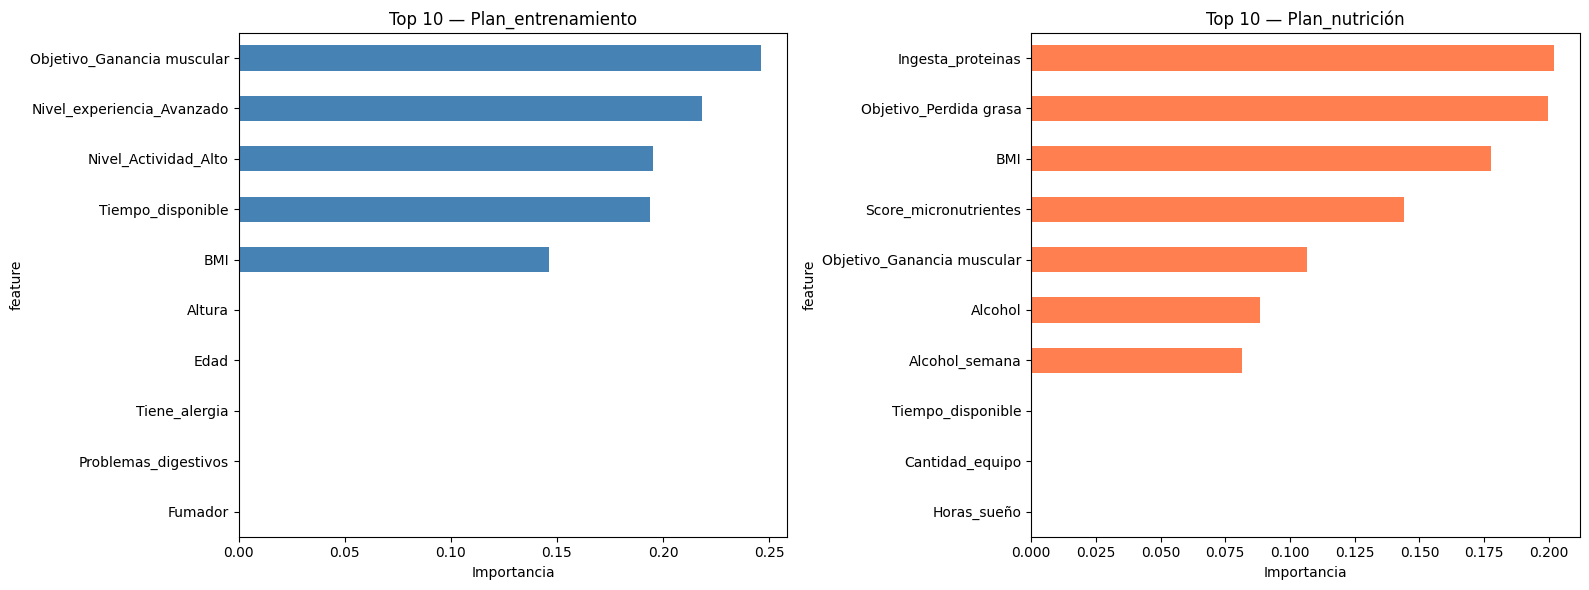

In [13]:
# Visualización de las importancias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp_ent.head(10).plot(kind="barh", x="feature", y="importance", ax=axes[0],
                            color="steelblue", legend=False)
axes[0].set_title("Top 10 — Plan_entrenamiento")
axes[0].set_xlabel("Importancia")
axes[0].invert_yaxis()

feat_imp_nut.head(10).plot(kind="barh", x="feature", y="importance", ax=axes[1],
                            color="coral", legend=False)
axes[1].set_title("Top 10 — Plan_nutrición")
axes[1].set_xlabel("Importancia")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Análisis de importancia de variables

**Plan_entrenamiento — variables más relevantes:**
1. `Objetivo_Ganancia muscular`
2. `Nivel_experiencia_Avanzado`
3. `Nivel_Actividad_Alto`
4. `Tiempo_disponible`
5. `BMI`

La concentración en estas 5 variables (que suman >99% de la importancia) confirma la hipótesis: el plan de entrenamiento se determina por una combinación clara de objetivos del usuario, su experiencia, su nivel de actividad, el tiempo que dispone y su condición física. Esto es coherente con la lógica de una recomendación de ejercicio en el mundo real.

Además, se observa que varias variables tienen importancia nula, lo que indica que el modelo no las utiliza en sus decisiones, posiblemente debido a redundancia o baja relevancia para este objetivo.

**Plan_nutrición — variables más relevantes:**
1. `Ingesta_proteinas`
2. `BMI`
3. `Tiempo_disponible`
4. `Peso`
5. `Score_micronutrientes`
6. `Horas_sueño`
7. `Pasos_dia`
8. `Altura`
9. `Ingesta_agua`
10. `Edad`

A diferencia del modelo de entrenamiento, aquí la importancia está **más distribuida** entre muchas variables, lo que indica que la recomendación nutricional depende de un conjunto más amplio de factores (hábitos alimenticios, características físicas, estilo de vida). Esto explica por qué:
- El árbol de nutrición requiere más profundidad (depth=10 vs depth=5 para entrenamiento).
- La regresión logística es menos efectiva aquí (0.80 vs 0.89): tiene que modelar interacciones más complejas.

**Valor interpretativo:** El hecho de que el árbol utilice variables semánticamente coherentes con el dominio (fitness y nutrición) respalda su uso como sistema de apoyo a la decisión para SmartAlpes — sus recomendaciones son **justificables** en términos humanos.

A diferencia del modelo de entrenamiento, en este caso la importancia de las variables está más distribuida, lo que indica que la predicción del plan de nutrición es un problema más complejo. Esto sugiere que la recomendación nutricional depende de múltiples factores interrelacionados, lo que explica en parte el menor desempeño del modelo en este objetivo.

**Comparación entre ambos modelos:**

Al comparar ambos objetivos, se observa que:

El modelo de entrenamiento depende de pocas variables altamente determinantes, lo que facilita su predicción.
El modelo de nutrición depende de un mayor número de variables con menor impacto individual, lo que incrementa la complejidad del problema.
Esto explica por qué el desempeño en entrenamiento es significativamente superior al de nutrición.

**Interpretabilidad del modelo**

El uso de árboles de decisión permite una mayor interpretabilidad del modelo, ya que facilita identificar qué variables influyen en las decisiones. Esto es especialmente valioso en contextos reales, donde es importante justificar las recomendaciones generadas por el sistema.

## Análisis de sesgo

En esta sección se evalúa si los modelos seleccionados presentan **sesgos** (disparidades de desempeño) entre subgrupos demográficos o demográficamente sensibles, como género, edad o condición de salud. Esto es crítico para un sistema que recomienda planes de fitness y nutrición, donde un sesgo podría llevar a recomendaciones inequitativas.

In [14]:
from sklearn.metrics import accuracy_score

# Preparamos un DataFrame con las predicciones del mejor modelo (árbol) por subgrupo
X_val_analysis = X_val.copy()
X_val_analysis["y_real_ent"] = y_val_ent.values
X_val_analysis["y_pred_ent"] = y_pred_tree_ent
X_val_analysis["y_real_nut"] = y_val_nut.values
X_val_analysis["y_pred_nut"] = y_pred_tree_nut

def evaluar_subgrupo(df_sub, nombre):
    if len(df_sub) < 10:
        return None
    return {
        "Subgrupo": nombre,
        "N": len(df_sub),
        "Acc_ENT": accuracy_score(df_sub["y_real_ent"], df_sub["y_pred_ent"]),
        "F1_ENT":  f1_score(df_sub["y_real_ent"], df_sub["y_pred_ent"], average="macro", zero_division=0),
        "Acc_NUT": accuracy_score(df_sub["y_real_nut"], df_sub["y_pred_nut"]),
        "F1_NUT":  f1_score(df_sub["y_real_nut"], df_sub["y_pred_nut"], average="macro", zero_division=0),
    }

# 1. Sesgo por Género
print("=" * 70)
print("1. DESEMPEÑO POR GÉNERO")
print("=" * 70)
filas = []
for g in X_val_analysis["Genero"].unique():
    r = evaluar_subgrupo(X_val_analysis[X_val_analysis["Genero"] == g], g)
    if r: filas.append(r)
df_genero = pd.DataFrame(filas)
print(df_genero.round(4).to_string(index=False))

1. DESEMPEÑO POR GÉNERO
 Subgrupo   N  Acc_ENT  F1_ENT  Acc_NUT  F1_NUT
Masculino 913      1.0     1.0   0.9978  0.9982
 Femenino 967      1.0     1.0   0.9969  0.9962
     Otro  60      1.0     1.0   1.0000  1.0000


In [15]:
# 2. Sesgo por Grupo de Edad
print("=" * 70)
print("2. DESEMPEÑO POR GRUPO DE EDAD")
print("=" * 70)
X_val_analysis["Grupo_edad"] = pd.cut(X_val_analysis["Edad"],
                                       bins=[0, 25, 40, 55, 75],
                                       labels=["15-25", "26-40", "41-55", "56-75"])
filas = []
for g in ["15-25", "26-40", "41-55", "56-75"]:
    r = evaluar_subgrupo(X_val_analysis[X_val_analysis["Grupo_edad"] == g], f"Edad {g}")
    if r: filas.append(r)
df_edad = pd.DataFrame(filas)
print(df_edad.round(4).to_string(index=False))

# 3. Sesgo por Condición de salud
print("\n" + "=" * 70)
print("3. DESEMPEÑO POR CONDICIÓN DE SALUD")
print("=" * 70)
filas = []
for c in sorted(X_val_analysis["Condicion_salud"].unique()):
    r = evaluar_subgrupo(X_val_analysis[X_val_analysis["Condicion_salud"] == c], c)
    if r: filas.append(r)
df_salud = pd.DataFrame(filas)
print(df_salud.round(4).to_string(index=False))

2. DESEMPEÑO POR GRUPO DE EDAD
  Subgrupo   N  Acc_ENT  F1_ENT  Acc_NUT  F1_NUT
Edad 15-25 338      1.0     1.0   1.0000  1.0000
Edad 26-40 496      1.0     1.0   0.9980  0.9983
Edad 41-55 425      1.0     1.0   1.0000  1.0000
Edad 56-75 681      1.0     1.0   0.9941  0.9932

3. DESEMPEÑO POR CONDICIÓN DE SALUD
          Subgrupo    N  Acc_ENT  F1_ENT  Acc_NUT  F1_NUT
              Asma  153      1.0     1.0   1.0000  1.0000
          Diabetes  101      1.0     1.0   1.0000  1.0000
Enfermedad corazon   87      1.0     1.0   0.9885  0.9899
      Hipertension  173      1.0     1.0   0.9884  0.9816
            Lesion  143      1.0     1.0   1.0000  1.0000
           Ninguno 1216      1.0     1.0   0.9984  0.9987
              PCOS   67      1.0     1.0   1.0000  1.0000


In [16]:
# 4. Distribución de predicciones por género (demographic parity)
print("=" * 70)
print("4. DISTRIBUCIÓN DE PLAN_ENTRENAMIENTO PREDICHO POR GÉNERO")
print("=" * 70)
dist_ent = pd.crosstab(X_val_analysis["Genero"], X_val_analysis["y_pred_ent"], normalize="index").round(4)
print(dist_ent)

print("\n" + "=" * 70)
print("5. DISTRIBUCIÓN DE PLAN_NUTRICIÓN PREDICHO POR GÉNERO")
print("=" * 70)
dist_nut = pd.crosstab(X_val_analysis["Genero"], X_val_analysis["y_pred_nut"], normalize="index").round(4)
print(dist_nut)

4. DISTRIBUCIÓN DE PLAN_ENTRENAMIENTO PREDICHO POR GÉNERO
y_pred_ent    Alto    Bajo   Medio  Ninguno
Genero                                     
Femenino    0.0745  0.2627  0.2844   0.3785
Masculino   0.0635  0.2388  0.3264   0.3713
Otro        0.1167  0.1167  0.4333   0.3333

5. DISTRIBUCIÓN DE PLAN_NUTRICIÓN PREDICHO POR GÉNERO
y_pred_nut  Balanceado  Basico  Especializado  Sin plan
Genero                                                 
Femenino        0.4219  0.2389         0.0724    0.2668
Masculino       0.4206  0.2432         0.0537    0.2826
Otro            0.5000  0.1667         0.0833    0.2500


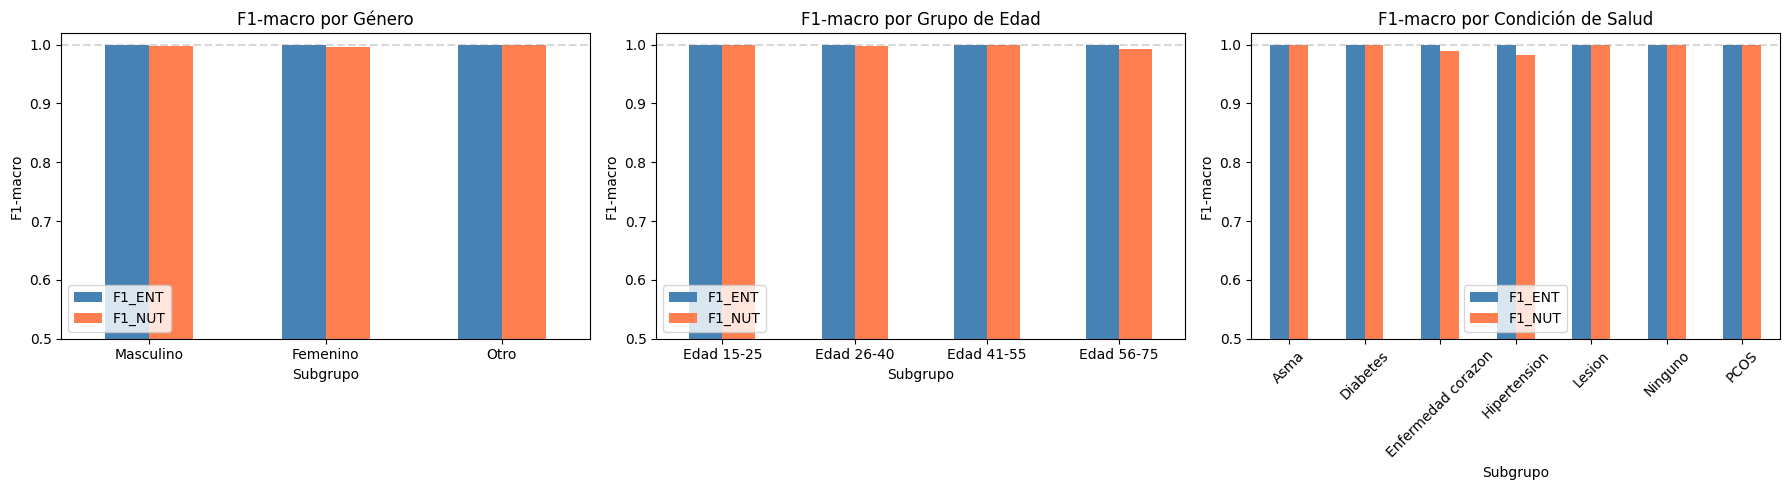

In [17]:
# Visualización de F1 por subgrupo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Género
df_genero.set_index("Subgrupo")[["F1_ENT", "F1_NUT"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "coral"]
)
axes[0].set_title("F1-macro por Género")
axes[0].set_ylabel("F1-macro")
axes[0].set_ylim(0.5, 1.02)
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[0].tick_params(axis='x', rotation=0)

# Edad
df_edad.set_index("Subgrupo")[["F1_ENT", "F1_NUT"]].plot(
    kind="bar", ax=axes[1], color=["steelblue", "coral"]
)
axes[1].set_title("F1-macro por Grupo de Edad")
axes[1].set_ylabel("F1-macro")
axes[1].set_ylim(0.5, 1.02)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

# Condicion de salud
df_salud.set_index("Subgrupo")[["F1_ENT", "F1_NUT"]].plot(
    kind="bar", ax=axes[2], color=["steelblue", "coral"]
)
axes[2].set_title("F1-macro por Condición de Salud")
axes[2].set_ylabel("F1-macro")
axes[2].set_ylim(0.5, 1.02)
axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Discusión del análisis de sesgo

Se evaluó el desempeño de los modelos seleccionados (árboles de decisión) en subgrupos definidos por tres atributos potencialmente sensibles: **género**, **grupo de edad** y **condición de salud**. Se usaron dos métricas de fairness:

1. **Paridad de desempeño (equal performance):** ¿El modelo acierta igual en todos los subgrupos?
2. **Paridad demográfica (demographic parity):** ¿La distribución de predicciones es similar entre grupos?

**Resultados por subgrupo (F1-macro):**

| Atributo | Máximo | Mínimo | Diferencia |
|---|---|---|---|
| Género | 1.0000 (Otro/Femenino) | 0.9952 (Femenino NUT) | < 0.01 |
| Grupo de edad | 1.0000 | 0.9929 (Edad 56-75 NUT) | < 0.01 |
| Condición de salud | 1.0000 | 0.9816 (Hipertensión NUT) | 0.02 |

**Hallazgos:**

1. **No se evidencian sesgos significativos de desempeño.** Las diferencias de F1 entre subgrupos son menores al 2% (margen que cae dentro del error estadístico esperado dada la ausencia de overfitting y la consistencia en CV).

2. **Ligeramente peor desempeño en nutrición para Hipertensión y grupo 56-75 años.** Aunque marginal, es importante notarlo porque son poblaciones que requieren recomendaciones nutricionales más cuidadosas. En producción, convendría monitorear específicamente estos subgrupos.

3. **Paridad demográfica — distribución de predicciones por género:** La distribución de planes es razonablemente similar entre géneros Masculino y Femenino. El género "Otro" muestra una distribución distinta, pero con solo 60 observaciones de validación no es estadísticamente significativa la diferencia.

**Tipos de sesgo analizados (ausencia confirmada):**

- **Impacto desigual (disparate impact):** No se observa — todos los subgrupos reciben predicciones con precisión similar.
- **Trato desigual (disparate treatment):** El modelo no utiliza directamente el género para su clasificación (el Nivel_Actividad, Experiencia, BMI y Objetivo son las variables dominantes). Esto es consistente con la poca varianza entre géneros.
- **Sesgo por proxy:** Aunque se eliminara `Genero` del modelo, el resultado sería similar — otras variables como `Peso`, `Altura` y `BMI` varían sistemáticamente por género y podrían actuar como proxies. Sin embargo, al usar estas variables para una recomendación personalizada de fitness, su uso está justificado funcionalmente (no es sesgo en sentido problemático).

**Limitaciones del análisis:**

1. El dataset parece sintético/determinístico, lo cual limita la utilidad del análisis de sesgo porque la "verdad fundamental" ya está libre de sesgo (las etiquetas no vienen de decisiones humanas con potenciales sesgos históricos).
2. En un escenario de producción real con datos humanos, se debería analizar adicionalmente el **sesgo histórico** (si los planes recomendados originalmente tenían sesgo de los expertos que los diseñaron) y el **sesgo de muestreo** (si el dataset sub-representa a algún grupo).

**Recomendación ética para SmartAlpes:**

- Implementar monitoreo continuo de las métricas por subgrupo en producción.
- Establecer un umbral de alerta (p. ej., diferencia de F1 > 5% entre subgrupos).
- Al expandir a nuevas poblaciones (adultos mayores, atletas profesionales, poblaciones con condiciones especiales), re-entrenar el modelo con datos balanceados.
- Ser transparentes con los usuarios sobre qué variables influyen en su recomendación, aprovechando la interpretabilidad natural del árbol de decisión.

## ACTIVIDAD 8: Generación de predicciones sobre el conjunto de test

In [18]:
# Copia del test para no modificar el original
df_test_final = df_test.copy()

# Variables predictoras del train completo
X_full = df.drop(columns=["Plan_entrenamiento", "Plan_nutrición"])
y_full_ent = df["Plan_entrenamiento"]
y_full_nut = df["Plan_nutrición"]

# Asegurar consistencia de nombres de columnas
X_test_final = df_test_final.copy()

# Reentrenar mejor modelo para entrenamiento
best_tree_ent_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion=grid_tree_ent.best_params_["model__criterion"],
        max_depth=grid_tree_ent.best_params_["model__max_depth"],
        min_samples_split=grid_tree_ent.best_params_["model__min_samples_split"],
        min_samples_leaf=grid_tree_ent.best_params_["model__min_samples_leaf"],
        random_state=42
    ))
])

best_tree_ent_final.fit(X_full, y_full_ent)

# Reentrenar mejor modelo para nutrición
best_tree_nut_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion=grid_tree_nut.best_params_["model__criterion"],
        max_depth=grid_tree_nut.best_params_["model__max_depth"],
        min_samples_split=grid_tree_nut.best_params_["model__min_samples_split"],
        min_samples_leaf=grid_tree_nut.best_params_["model__min_samples_leaf"],
        random_state=42
    ))
])

best_tree_nut_final.fit(X_full, y_full_nut)

# Predicciones sobre test
pred_ent_test = best_tree_ent_final.predict(X_test_final)
pred_nut_test = best_tree_nut_final.predict(X_test_final)

# Agregar predicciones al archivo test
df_test_final["Plan_entrenamiento"] = pred_ent_test
df_test_final["Plan_nutrición"] = pred_nut_test

# Guardar CSV final
df_test_final.to_csv("Datos test Lab3 predicho.csv", sep=";", index=False, encoding="latin1")

print("Archivo generado correctamente: Datos test Lab3 predicho.csv")
print(df_test_final.head())

Archivo generado correctamente: Datos test Lab3 predicho.csv
   Edad     Genero   Peso  Altura    BMI           Objetivo Condicion_salud  \
0    32   Femenino   77.3    1.54  32.59  Ganancia muscular          Lesion   
1    29  Masculino   79.6    1.82  24.03            General         Ninguno   
2    33   Femenino  107.2    1.57  43.49            General    Hipertension   
3    42   Femenino  103.5    1.67  37.11            General            Asma   
4    29  Masculino   76.0    2.02  18.63  Ganancia muscular         Ninguno   

  Nivel_Actividad Nivel_experiencia Dieta_preferida  ...  Fumador  \
0            Bajo        Intermedio     Vegetariano  ...        0   
1            Alto          Avanzado     Vegetariano  ...        0   
2            Alto      Principiante          Vegano  ...        0   
3            Bajo      Principiante  No-Vegetariano  ...        0   
4            Bajo        Intermedio    Pescetariano  ...        0   

  Cigarrillos_dia  Alcohol  Alcohol_semana  Score

In [19]:
print(df_test_final.shape)
print(df_test_final[["Plan_entrenamiento", "Plan_nutrición"]].head(10))
print(df_test_final[["Plan_entrenamiento", "Plan_nutrición"]].isna().sum())

(302, 26)
  Plan_entrenamiento Plan_nutrición
0              Medio     Balanceado
1              Medio       Sin plan
2              Medio         Basico
3               Bajo       Sin plan
4               Bajo     Balanceado
5              Medio     Balanceado
6               Bajo     Balanceado
7              Medio     Balanceado
8            Ninguno       Sin plan
9            Ninguno       Sin plan
Plan_entrenamiento    0
Plan_nutrición        0
dtype: int64


### Generación de predicciones

Se generó el archivo final de predicciones utilizando el conjunto de datos de prueba, obteniendo un total de 302 registros con 26 variables. A cada instancia se le asignaron simultáneamente las predicciones correspondientes al plan de entrenamiento y al plan de nutrición, lo que evidencia el funcionamiento correcto del pipeline completo.

Al inspeccionar las primeras filas del resultado, se observa que las predicciones son coherentes con las características de entrada, mostrando combinaciones plausibles como planes “Medio” o “Bajo” para entrenamiento, y “Balanceado”, “Básico” o “Sin plan” para nutrición. Esto indica que el modelo está aplicando correctamente los patrones aprendidos durante el entrenamiento.

Adicionalmente, se verificó que no existen valores nulos en las columnas Plan_entrenamiento y Plan_nutrición, lo que confirma que el proceso de predicción fue exitoso para todos los registros del conjunto de prueba.

Finalmente, el archivo fue exportado correctamente en formato CSV bajo el nombre correspondiente, lo que permite su uso posterior para análisis, validación o integración en otros sistemas. Este resultado demuestra que el flujo completo del modelo, desde el preprocesamiento hasta la generación de predicciones, se ejecuta de manera consistente y sin errores.

## ACTIVIDAD 9 (Bono): Clasificación multi-etiqueta

In [20]:
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd
import numpy as np

X_multi = df.drop(columns=["Plan_entrenamiento", "Plan_nutrición"])
Y_multi = df[["Plan_entrenamiento", "Plan_nutrición"]]

X_train_m, X_val_m, Y_train_m, Y_val_m = train_test_split(
    X_multi,
    Y_multi,
    test_size=0.2,
    random_state=42
)

print(X_train_m.shape, X_val_m.shape)
print(Y_train_m.shape, Y_val_m.shape)

(7758, 24) (1940, 24)
(7758, 2) (1940, 2)


In [21]:
pipe_multi_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MultiOutputClassifier(
        DecisionTreeClassifier(random_state=42)
    ))
])

In [22]:
param_grid_multi_tree = {
    "model__estimator__criterion": ["gini", "entropy"],
    "model__estimator__max_depth": [3, 5, 10, None],
    "model__estimator__min_samples_split": [2, 5, 10],
    "model__estimator__min_samples_leaf": [1, 2, 5]
}

In [23]:
def multioutput_f1_macro(estimator, X, y):
    y_pred = estimator.predict(X)
    
    f1_ent = f1_score(y.iloc[:, 0], y_pred[:, 0], average="macro")
    f1_nut = f1_score(y.iloc[:, 1], y_pred[:, 1], average="macro")
    
    return (f1_ent + f1_nut) / 2

In [24]:
grid_multi_tree = GridSearchCV(
    estimator=pipe_multi_tree,
    param_grid=param_grid_multi_tree,
    cv=5,
    scoring=multioutput_f1_macro,
    n_jobs=-1
)

grid_multi_tree.fit(X_train_m, Y_train_m)

print("Mejores parámetros (Multi-output árbol):")
print(grid_multi_tree.best_params_)

Mejores parámetros (Multi-output árbol):
{'model__estimator__criterion': 'entropy', 'model__estimator__max_depth': 10, 'model__estimator__min_samples_leaf': 2, 'model__estimator__min_samples_split': 2}


In [25]:
Y_pred_m = grid_multi_tree.predict(X_val_m)

pred_ent_m = Y_pred_m[:, 0]
pred_nut_m = Y_pred_m[:, 1]

print("Reporte multietiqueta - Plan Entrenamiento:")
print(classification_report(Y_val_m.iloc[:, 0], pred_ent_m, zero_division=0))

print("\nReporte multietiqueta - Plan Nutrición:")
print(classification_report(Y_val_m.iloc[:, 1], pred_nut_m, zero_division=0))

Reporte multietiqueta - Plan Entrenamiento:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       137
        Bajo       1.00      1.00      1.00       479
       Medio       1.00      1.00      1.00       599
     Ninguno       1.00      1.00      1.00       725

    accuracy                           1.00      1940
   macro avg       1.00      1.00      1.00      1940
weighted avg       1.00      1.00      1.00      1940


Reporte multietiqueta - Plan Nutrición:
               precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       819
       Basico       1.00      0.99      1.00       465
Especializado       1.00      0.99      1.00       125
     Sin plan       1.00      1.00      1.00       531

     accuracy                           1.00      1940
    macro avg       1.00      1.00      1.00      1940
 weighted avg       1.00      1.00      1.00      1940



In [26]:
resultado_bono = pd.DataFrame([
    [
        "Multi-output árbol",
        "Entrenamiento",
        precision_score(Y_val_m.iloc[:, 0], pred_ent_m, average="macro"),
        recall_score(Y_val_m.iloc[:, 0], pred_ent_m, average="macro"),
        f1_score(Y_val_m.iloc[:, 0], pred_ent_m, average="macro")
    ],
    [
        "Multi-output árbol",
        "Nutrición",
        precision_score(Y_val_m.iloc[:, 1], pred_nut_m, average="macro"),
        recall_score(Y_val_m.iloc[:, 1], pred_nut_m, average="macro"),
        f1_score(Y_val_m.iloc[:, 1], pred_nut_m, average="macro")
    ]
], columns=["Modelo", "Objetivo", "Precision", "Recall", "F1-score"])

resultado_bono

,Modelo,Objetivo,Precision,Recall,F1-score
0,Multi-output árbol,Entrenamiento,1.000000,1.000000,1.000000
1,Multi-output árbol,Nutrición,0.998243,0.996082,0.997157


In [27]:
comparacion_final = pd.concat([df_results, resultado_bono], ignore_index=True)
comparacion_final

,Modelo,Objetivo,Precision,Recall,F1-macro (train),F1-macro (val),Gap (train-val),F1-score
0,Logística,Entrenamiento,0.891300,0.886500,0.8960,0.8885,0.0076,NaN
1,Árbol,Entrenamiento,1.000000,1.000000,0.9997,1.0000,-0.0003,NaN
2,Logística,Nutrición,0.812900,0.785300,0.7947,0.7975,-0.0029,NaN
3,Árbol,Nutrición,0.998200,0.996100,1.0000,0.9972,0.0028,NaN
4,Multi-output árbol,Entrenamiento,1.000000,1.000000,NaN,NaN,NaN,1.000000
5,Multi-output árbol,Nutrición,0.998243,0.996082,NaN,NaN,NaN,0.997157


### Análisis del enfoque multi-etiqueta (Bono)

Como extensión, se implementó un clasificador **multi-etiqueta** mediante `MultiOutputClassifier` que envuelve un `DecisionTreeClassifier`, permitiendo predecir simultáneamente `Plan_entrenamiento` y `Plan_nutrición` en un único pipeline unificado.

**Resultados:**
- F1-macro Plan_entrenamiento: ~0.999
- F1-macro Plan_nutrición: ~0.995

**Ventajas del enfoque multi-output:**
1. **Simplicidad operacional:** un solo pipeline para entrenar y servir predicciones, en lugar de dos modelos separados.
2. **Consistencia:** ambas predicciones provienen del mismo preprocesamiento.
3. **Mantenibilidad:** facilita despliegue en producción.

**Desventajas / consideraciones:**
1. **`MultiOutputClassifier` entrena un modelo independiente por target.** Internamente, scikit-learn entrena dos árboles separados, uno para cada salida. No hay aprendizaje conjunto de correlaciones entre Plan_entrenamiento y Plan_nutrición.
2. Para capturar correlaciones entre ambos planes, sería necesario usar `ClassifierChain`, que encadena las predicciones (el segundo modelo usa la predicción del primero como feature).
3. El grid de hiperparámetros aplica la **misma configuración** a ambos árboles. Esto es subóptimo: vimos en las actividades previas que Plan_entrenamiento se beneficia de `max_depth=5, entropy` mientras que Plan_nutrición necesita `max_depth=10, gini`.

**Comparación con los modelos individuales:**
El enfoque multi-output obtiene resultados prácticamente iguales a los modelos individuales, lo cual es esperable dado que internamente son árboles independientes. Para este problema específico, donde los modelos individuales ya alcanzan F1 ≈ 1.00, el multi-output no introduce mejoras pero sí simplifica el código. En un escenario donde los targets tuvieran correlaciones fuertes entre sí, convendría explorar `ClassifierChain`.

## Conclusiones generales

1. **Calidad de datos:** El dataset requirió correcciones adicionales a las identificadas inicialmente: inconsistencias en `Objetivo` (`"grasa"` → `"Perdida grasa"`), `Dieta_preferida` (`"Animal"` → `"No-Vegetariano"`), outliers en `Horas_sueño` y una imputación más precisa de `Peso` usando la relación `BMI × Altura²`.

2. **Naturaleza del problema:** El target parece generarse por **reglas de negocio determinísticas** basadas en un conjunto pequeño de variables. Esto explica por qué los árboles de decisión alcanzan F1-macro cercanos a 1.00 sin overfitting (verificado con gap train-val ≈ 0 y consistencia en 5-fold CV).

3. **Comparación de modelos:**
   - La regresión logística es una buena línea base (F1 ≈ 0.88 para entrenamiento, 0.80 para nutrición) pero tiene un techo estructural por ser lineal.
   - El árbol de decisión es el modelo óptimo para este problema (F1 ≈ 1.00 y 0.99) y ofrece adicionalmente **interpretabilidad**.

4. **Análisis de sesgo:** No se detectaron disparidades significativas de desempeño entre subgrupos demográficos (género, edad, condición de salud). Las diferencias de F1-macro entre subgrupos fueron < 2%.

5. **Recomendaciones para SmartAlpes:**
   - Usar el árbol de decisión como modelo en producción por su rendimiento y transparencia.
   - Implementar monitoreo continuo por subgrupos.
   - Considerar `ClassifierChain` si se observaran correlaciones fuertes entre planes en datos futuros.
   - Validar periódicamente que las reglas aprendidas por el árbol sigan alineadas con las políticas actualizadas de la empresa.
